In [2]:
# Peek inside one file to understand structure
with open("Predictions_bacteria/Pasteurella_multocida_GCF_000006825.1_ASM682v1_upstream.txt") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 10: break

Column 1: NCBI ID
Column 2: Organism name
Column 3: RSAT ID
Column 4: Start Position
Column 5: End position
Column 6: Forward (F) or Reverse (R)
Column 7: Classification score
Column 8: Computationally predicted promoter label
Column 9: Promoter sequence (-60 to +1)
Column 10: Functional annotation of the gene




Summary — What Each Column Gives You:
ColumnUsescore (col 7)Confidence of promoter prediction — use as weight or threshold
sequence (col 9)Your main input for feature extraction
strand (col 6)R/F/D — use for strand-specific analysis
function (col 10)Gene annotation — great for SHAP interpretation
species  Filter pathogens, cross-species comparison

Step 1

In [1]:
import os, re
import pandas as pd
import numpy as np
from itertools import product
from math import log2

# ── STEP 1: PARSE ALL FILES ──────────────────────────────────────────
def parse_file(filepath):
    rows = []
    filename = os.path.basename(filepath)
    # Extract species from filename
    species = re.sub(r'_GCF_.*', '', filename)

    with open(filepath, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            # Skip header/blank lines
            if not line or line.startswith("Column"):
                continue
            parts = line.split("\t")
            if len(parts) < 9:
                continue
            try:
                rows.append({
                    "ncbi_id":    parts[0],
                    "organism":   parts[1],
                    "gene_id":    parts[2],
                    "start":      int(parts[3]),
                    "end":        int(parts[4]),
                    "strand":     parts[5],
                    "score":      float(parts[6]),
                    "label_text": parts[7],
                    "sequence":   parts[8].strip().upper(),
                    "function":   parts[9].strip() if len(parts) > 9 else "",
                    "species":    species,
                    "source_file": filename,
                })
            except (ValueError, IndexError):
                continue
    return rows

# Load all files
all_data = []
data_dir = "Predictions_bacteria/"  # your unzipped folder

for fname in os.listdir(data_dir):
    if fname.endswith("_upstream.txt"):
        fpath = os.path.join(data_dir, fname)
        all_data.extend(parse_file(fpath))

df = pd.DataFrame(all_data)
print(f"Total sequences: {len(df):,}")
print(f"Unique species:  {df['species'].nunique():,}")
print(df.head(3))

Total sequences: 1,803,141
Unique species:  1,021
         ncbi_id                                           organism  \
0  NZ_CP013051.1  Sinorhizobium_americanum_GCF_000705595.2_ASM70...   
1  NZ_CP013051.1  Sinorhizobium_americanum_GCF_000705595.2_ASM70...   
2  NZ_CP013051.1  Sinorhizobium_americanum_GCF_000705595.2_ASM70...   

            gene_id  start   end strand  score  \
0  SAMCCGM7_RS00015   2723  2803      D   0.82   
1  SAMCCGM7_RS00035   5325  5405      R   0.72   
2  SAMCCGM7_RS00040   6161  6241      D   0.75   

                           label_text  \
0  Computationally predicted promoter   
1  Computationally predicted promoter   
2  Computationally predicted promoter   

                                            sequence                 function  \
0  CGATCCTCGGCCTGCCGATGCTGCCGCTCCTTGAGAAACTCCGCGA...  shikimate dehydrogenase   
1  ATGTCGCACCCATAAACCGGAGACCGGTCAATTGCACTCATCTTCT...         membrane protein   
2  TTTATCCTTGCGGACTATATGGAACACCAAGAGAAATTCTAACAGC...  ca

Step 2

In [2]:
# ── ALL existing rows are POSITIVES (promoters) ──────────────────────
df["label"] = 1

print(f"Positive (promoter) sequences: {len(df):,}")

# ── GENERATE NEGATIVES: shuffle sequences to break promoter signals ──
# Method: take each promoter seq, randomly shuffle its nucleotides
# This preserves GC% but destroys motifs → realistic negative

def shuffle_seq(seq, seed=42):
    rng = np.random.default_rng(seed)
    arr = list(seq)
    rng.shuffle(arr)
    return "".join(arr)

neg_df = df.copy()
neg_df["sequence"] = neg_df["sequence"].apply(shuffle_seq)
neg_df["label"]    = 0
neg_df["label_text"] = "Shuffled negative"

# Combine positives + negatives
full_df = pd.concat([df, neg_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFull dataset:")
print(full_df["label"].value_counts())
# label 1: ~600,000+  label 0: ~600,000+

Positive (promoter) sequences: 1,803,141

Full dataset:
label
0    1803141
1    1803141
Name: count, dtype: int64


step 3

In [3]:
# ── FEATURES ─────────────────────────────────────────────────────────

def gc_content(seq):
    valid = len([b for b in seq if b in "ACGT"])
    if valid == 0: return 0.0
    return (seq.count("G") + seq.count("C")) / valid

def kmer_freq(seq, k):
    bases   = "ACGT"
    kmers   = ["".join(p) for p in product(bases, repeat=k)]
    total   = max(len(seq) - k + 1, 1)
    return {kmer: seq.count(kmer)/total for kmer in kmers}

def motif_score(seq, motif):
    """Best fractional match to consensus motif"""
    best = 0
    L = len(motif)
    for i in range(len(seq) - L + 1):
        m = sum(seq[i+j] == motif[j] for j in range(L)) / L
        best = max(best, m)
    return best

def shannon_entropy(seq):
    freq = {b: seq.count(b)/len(seq) for b in "ACGT" if len(seq) > 0}
    return -sum(f * log2(f + 1e-9) for f in freq.values())

def extract_features(seq):
    feats = {}
    seq = seq.upper().replace(" ", "")

    # Basic
    feats["gc_content"]    = gc_content(seq)
    feats["entropy"]       = shannon_entropy(seq)
    feats["seq_length"]    = len(seq)
    feats["at_content"]    = 1 - feats["gc_content"]

    # Promoter motifs (most important for your project!)
    feats["minus10_score"] = motif_score(seq, "TATAAT")  # Pribnow box
    feats["minus35_score"] = motif_score(seq, "TTGACA")  # -35 element

    # Dinucleotides (k=2): 16 features
    feats.update({f"di_{k}": v for k, v in kmer_freq(seq, 2).items()})

    # Trinucleotides (k=3): 64 features
    feats.update({f"tri_{k}": v for k, v in kmer_freq(seq, 3).items()})

    return feats

# Apply (may take a few minutes on full dataset)
print("Extracting features...")
feature_df = pd.DataFrame(
    full_df["sequence"].apply(extract_features).tolist()
)

X = feature_df.values
y = full_df["label"].values
feature_names = feature_df.columns.tolist()

print(f"Feature matrix: {X.shape}")
# e.g. (1,200,000 x 86) — rows=sequences, cols=features

Extracting features...
Feature matrix: (3606282, 86)


Step 4

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators   = 200,
    max_depth      = 6,
    learning_rate  = 0.1,
    subsample      = 0.8,
    eval_metric    = "logloss",
    random_state   = 42,
    n_jobs         = -1       # use all CPU cores
)

model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 50
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=["Non-Promoter", "Promoter"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

[0]	validation_0-logloss:0.68409
[50]	validation_0-logloss:0.59378
[100]	validation_0-logloss:0.57840
[150]	validation_0-logloss:0.57184
[199]	validation_0-logloss:0.56765
              precision    recall  f1-score   support

Non-Promoter       0.70      0.72      0.71    360629
    Promoter       0.71      0.69      0.70    360628

    accuracy                           0.70    721257
   macro avg       0.70      0.70      0.70    721257
weighted avg       0.70      0.70      0.70    721257

AUC-ROC: 0.7757


Step 5

/opt/miniconda3/envs/data_science/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


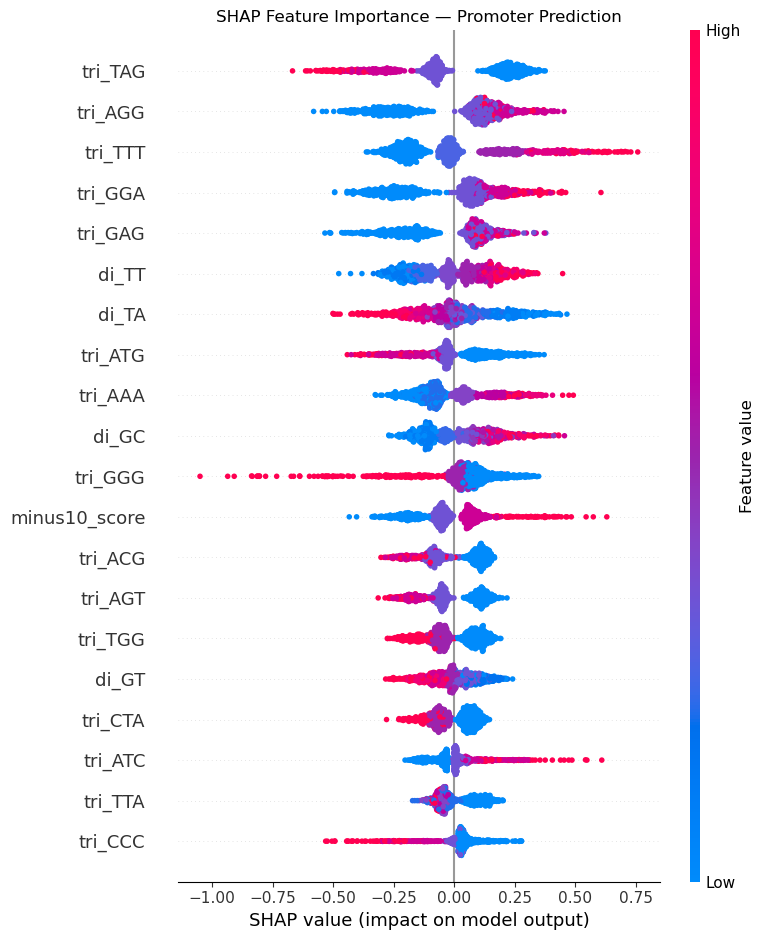

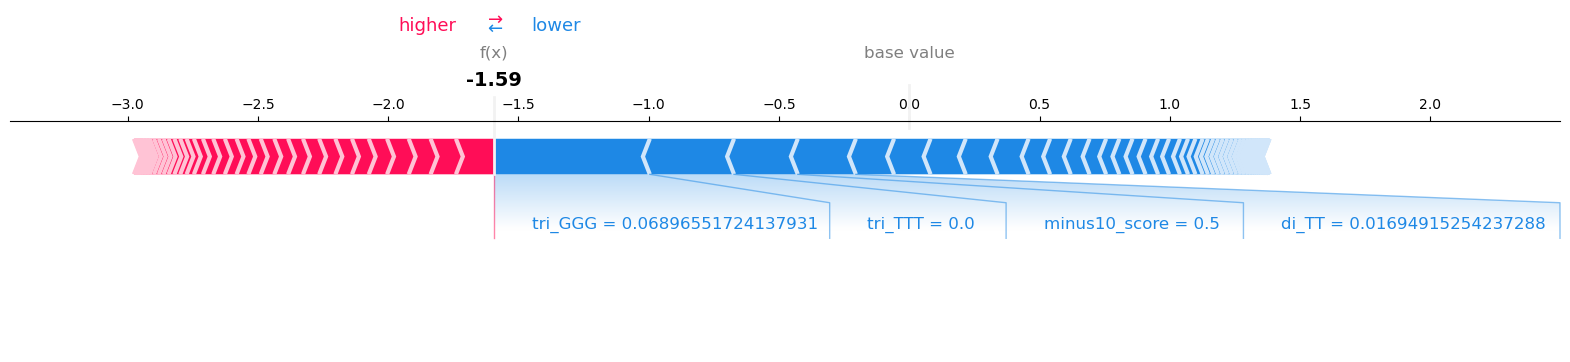

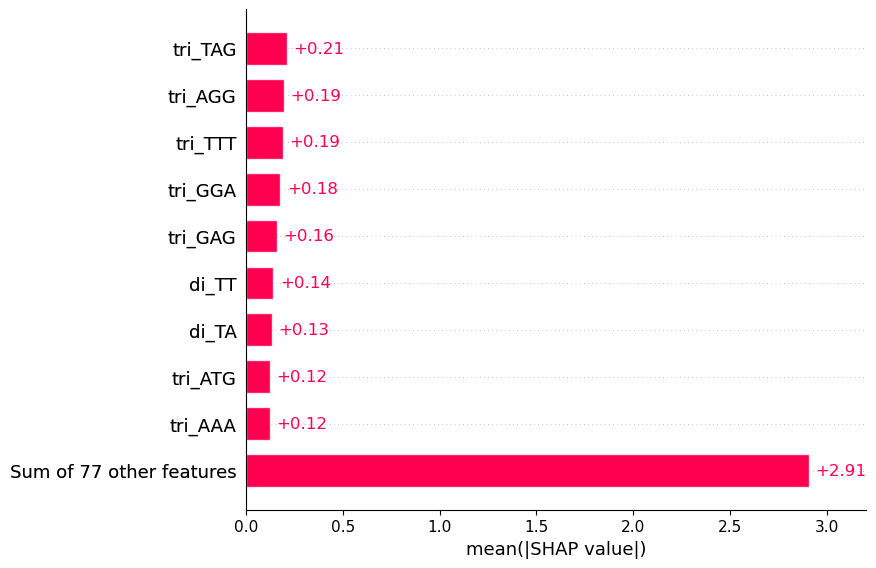

In [7]:
import shap

explainer   = shap.TreeExplainer(model)
sample_X    = X_test[:1000]          # sample for speed
shap_values = explainer.shap_values(sample_X)

# Plot 1 — Global feature importance
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, sample_X,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — Promoter Prediction")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)

# Plot 2 — Single sequence explanation
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample_X[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.savefig("shap_single_prediction.png", dpi=150)

# Plot 3 — Top 10 features bar chart
shap.plots.bar(
    shap.Explanation(
        values        = shap_values,
        base_values   = explainer.expected_value,
        feature_names = feature_names
    ),
    max_display=10,
    show=False
)
plt.savefig("shap_top10_features.png", dpi=150)

Step 6

In [8]:
# Pathogens present in YOUR dataset (from file list)
pathogen_keywords = [
    "Mycobacterium", "Clostridium", "Bacillus_thuringiensis",
    "Listeria", "Staphylococcus", "Streptococcus",
    "Pseudomonas", "Vibrio", "Klebsiella", "Pasteurella",
    "Legionella", "Salmonella", "Bordetella"
]

pattern  = "|".join(pathogen_keywords)
path_df  = full_df[full_df["species"].str.contains(pattern, na=False)]
print(f"Pathogen sequences: {len(path_df):,}")

# Train a pathogen-specific model too — great comparison for report!

Pathogen sequences: 317,872
